<a href="https://colab.research.google.com/github/mohduzr02/DCF-MODEL/blob/main/Dissertation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing library
Pandas
Numpy
SciKit Learn
Yfinance
Statsmodel
Matplotlib
Seaborn

In [265]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.model_selection as sklearn
import statsmodels.api as sm
import yfinance as yf


## Downloading Data
Downloading data from web using yfinance ,cctx

Ticker:^NSEI,BTC-INR,^GSPC,INR=X,GC=F,USDINR=X,GOLDBEES.NS,LTGILTBEES.NS

In [266]:
Ticker = ['^NSEI','BTC-INR','^GSPC','USDINR=X','GOLDBEES.NS','LTGILTBEES.NS']
df_s = yf.download(Ticker,start="2019-06-01",interval="1wk",auto_adjust= True)

[*********************100%***********************]  6 of 6 completed


## Cleaning Data

In [267]:
df_s.head(5)

Price             Close                                                    \
Ticker          BTC-INR GOLDBEES.NS LTGILTBEES.NS   USDINR=X        ^GSPC   
Date                                                                        
2019-05-27  608332.1250         NaN           NaN  69.980003          NaN   
2019-06-03  533207.9375   28.906500           NaN  69.360001  2873.340088   
2019-06-10  627632.2500   29.242001           NaN  69.859001  2886.979980   
2019-06-17  755315.6250   29.764999         19.35  69.779999  2950.459961   
2019-06-24  745848.3125   29.979500         19.40  69.324997  2941.760010   

Price                            High                                       \
Ticker             ^NSEI      BTC-INR GOLDBEES.NS LTGILTBEES.NS   USDINR=X   
Date                                                                         
2019-05-27           NaN  612945.1875         NaN           NaN  69.980003   
2019-06-03  11870.650391  608377.1250   29.080000           NaN  69.625000   
2019-06-10  11823.299805  652381.0625   29.350000           NaN  69.842003   
2019-06-17  11724.099609  782619.1875   30.485001         19.51  70.112503   
2019-06-24  11788.849609  954577.3750   30.600000         20.40  69.769997   

Price       ...          Open                                        \
Ticker      ... LTGILTBEES.NS   USDINR=X        ^GSPC         ^NSEI   
Date        ...                                                       
2019-05-27  ...           NaN  69.804001          NaN           NaN   
2019-06-03  ...           NaN  69.570503  2751.530029  11953.750000   
2019-06-10  ...           NaN  69.348000  2885.830078  11934.900391   
2019-06-17  ...         19.41  69.825996  2889.750000  11844.000000   
2019-06-24  ...         19.90  69.608002  2951.419922  11725.799805   

Price               Volume                                                   \
Ticker             BTC-INR GOLDBEES.NS LTGILTBEES.NS USDINR=X         ^GSPC   
Date                                                                          
2019-05-27   2974837041750         NaN           NaN        0           NaN   
2019-06-03   9711513949360   8287800.0           NaN        0  1.802677e+10   
2019-06-10   9406958260890   8164300.0           NaN        0  1.589421e+10   
2019-06-17   9494838400010   9337900.0       32698.0        0  1.851676e+10   
2019-06-24  15305445145820  11723400.0       78448.0        0  1.881289e+10   

Price                  
Ticker          ^NSEI  
Date                   
2019-05-27        NaN  
2019-06-03  1322200.0  
2019-06-10  1757400.0  
2019-06-17  2018300.0  
2019-06-24  1690100.0  

[5 rows x 30 columns]

In [268]:
df_s=df_s.drop(columns=["High","Low","Open","Volume"], axis=1)

In [269]:
df_s.to_csv('Dataset.csv')

In [270]:
print(df_s.shape)
print()
print(df_s.dtypes)
print()
print(df_s.isnull().sum())


(384, 6)

Price  Ticker       
Close  BTC-INR          float64
       GOLDBEES.NS      float64
       LTGILTBEES.NS    float64
       USDINR=X         float64
       ^GSPC            float64
       ^NSEI            float64
dtype: object

Price  Ticker       
Close  BTC-INR          0
       GOLDBEES.NS      1
       LTGILTBEES.NS    3
       USDINR=X         0
       ^GSPC            1
       ^NSEI            1
dtype: int64


In [271]:
df_s=  df_s.dropna()

In [272]:
print(df_s.isnull().sum())

Price  Ticker       
Close  BTC-INR          0
       GOLDBEES.NS      0
       LTGILTBEES.NS    0
       USDINR=X         0
       ^GSPC            0
       ^NSEI            0
dtype: int64


## Statistical Anlalysis on return

In [273]:
df_return = df_s.pct_change().round(4).dropna()

In [274]:
print(df_return.describe())

Price        Close                                                    \
Ticker     BTC-INR GOLDBEES.NS LTGILTBEES.NS    USDINR=X       ^GSPC   
count   380.000000  380.000000    380.000000  380.000000  380.000000   
mean      0.009431    0.265678      0.001139    0.000856    0.002852   
std       0.079573    5.155047      0.006331    0.006649    0.025426   
min      -0.335700   -0.989900     -0.039400   -0.023400   -0.149800   
25%      -0.028100   -0.008475     -0.001725   -0.002500   -0.010300   
50%       0.004100    0.003750      0.001000    0.000500    0.004650   
75%       0.052650    0.014575      0.003700    0.004025    0.015800   
max       0.273600  100.485900      0.037400    0.030200    0.121000   

Price               
Ticker       ^NSEI  
count   380.000000  
mean      0.001993  
std       0.022908  
min      -0.121500  
25%      -0.010600  
50%       0.003300  
75%       0.015025  
max       0.127200  


In [275]:
# Finding Corrupted price Date of gold (MAX)
bad_date=df_return[('Close',"GOLDBEES.NS")].idxmax()
print(bad_date)

# Drop corrupted price
df_return_clean = df_return.drop(index=bad_date)
print(df_return_clean[("Close","GOLDBEES.NS")].describe())

2019-12-23 00:00:00
count    379.000000
mean       0.001245
std        0.055064
min       -0.989900
25%       -0.008550
50%        0.003700
75%        0.014450
max        0.081800
Name: (Close, GOLDBEES.NS), dtype: float64


In [276]:
## Finding Corrupted price Date of gold (MIN)
bad_date1=df_return_clean[('Close',"GOLDBEES.NS")].idxmin()
print(bad_date)

# Drop corrupted price
df_return_F = df_return_clean.drop(index=bad_date1)
print(df_return_F[("Close","GOLDBEES.NS")].describe())

2019-12-23 00:00:00
count    378.000000
mean       0.003867
std        0.020674
min       -0.071100
25%       -0.008350
50%        0.003750
75%        0.014475
max        0.081800
Name: (Close, GOLDBEES.NS), dtype: float64


In [277]:
print(df_return_F.describe())

Price        Close                                                    \
Ticker     BTC-INR GOLDBEES.NS LTGILTBEES.NS    USDINR=X       ^GSPC   
count   378.000000  378.000000    378.000000  378.000000  378.000000   
mean      0.009350    0.003867      0.001094    0.000837    0.002808   
std       0.079742    0.020674      0.006311    0.006662    0.025483   
min      -0.335700   -0.071100     -0.039400   -0.023400   -0.149800   
25%      -0.028300   -0.008350     -0.001775   -0.002500   -0.010300   
50%       0.004100    0.003750      0.000950    0.000500    0.004300   
75%       0.052500    0.014475      0.003600    0.003975    0.015775   
max       0.273600    0.081800      0.037400    0.030200    0.121000   

Price               
Ticker       ^NSEI  
count   378.000000  
mean      0.001969  
std       0.022958  
min      -0.121500  
25%      -0.010600  
50%       0.003300  
75%       0.014975  
max       0.127200  


## Naming the assets

In [278]:
df = df_return_F.copy()
df.columns = df.columns.get_level_values(1)  # BTC-INR, GOLDBEES.NS etc
df = df.rename(columns={
    'BTC-INR':'BTC',
    'GOLDBEES.NS':'Gold',
    'LTGILTBEES.NS':'Bond',
    'USDINR=X':'USDINR',
    '^GSPC':'SP500',
    '^NSEI':'Nifty'
})

df.to_csv("Final price.csv")

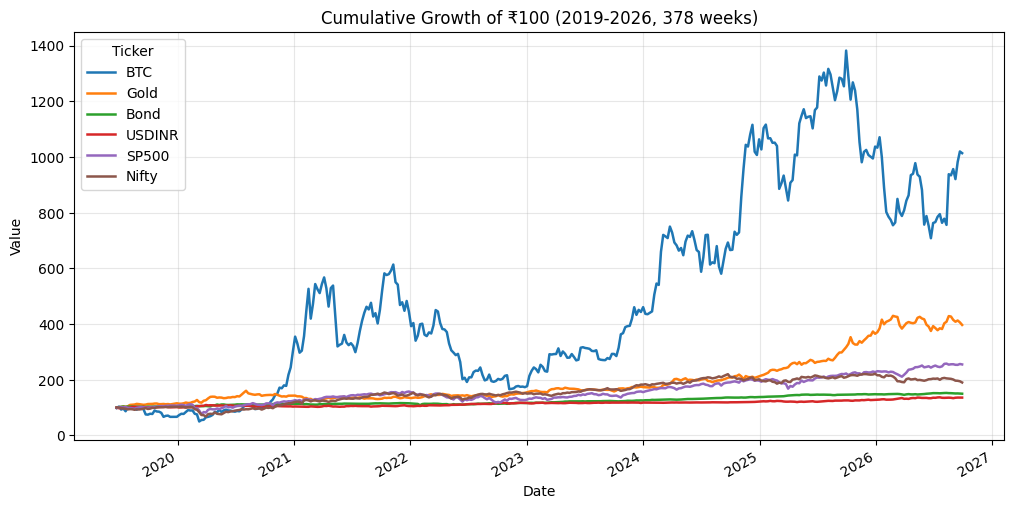

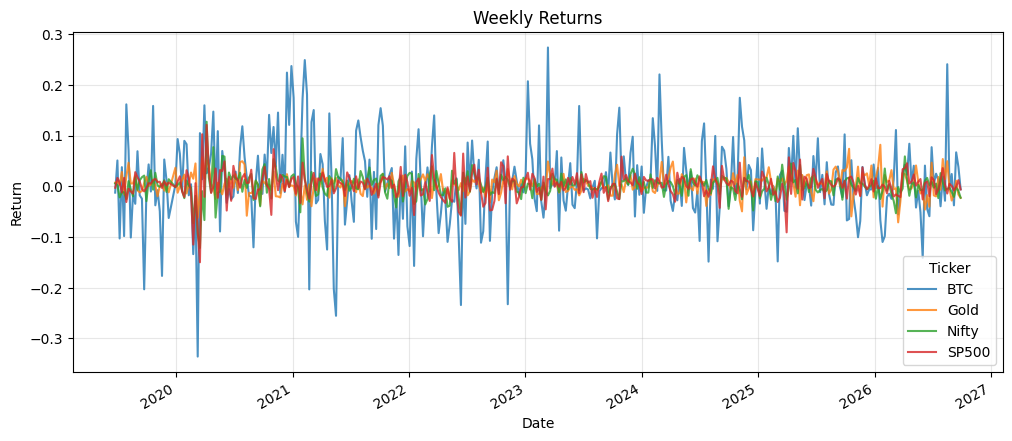

/tmp/ipykernel_900/3853481729.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (ann_vol[i], ann_ret[i]))


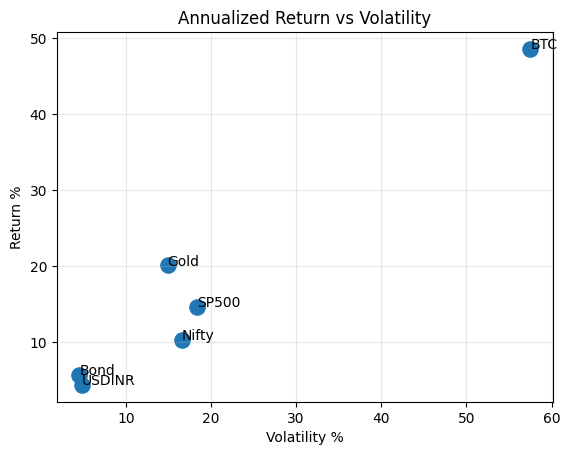

In [279]:
# 1. Cumulative growth of Rs 100
cum_wealth = (1 + df).cumprod() * 100
cum_wealth.plot(figsize=(12,6), linewidth=1.8)
plt.title('Cumulative Growth of ₹100 (2019-2026, 378 weeks)')
plt.ylabel('Value')
plt.grid(alpha=0.3)
plt.show()

# 2. Weekly returns
df[['BTC','Gold','Nifty','SP500']].plot(figsize=(12,5), alpha=0.8)
plt.title('Weekly Returns')
plt.ylabel('Return')
plt.grid(alpha=0.3)
plt.show()

# 3. Return vs Risk
ann_ret = df.mean()*52*100
ann_vol = df.std()*(52**0.5)*100
plt.scatter(ann_vol, ann_ret, s=120)
for i, txt in enumerate(ann_vol.index):
    plt.annotate(txt, (ann_vol[i], ann_ret[i]))
plt.xlabel('Volatility %')
plt.ylabel('Return %')
plt.title('Annualized Return vs Volatility')
plt.grid(alpha=0.3)
plt.show()

In [280]:
## Correlation Matrix
corr = df.corr().round(3)
print(corr)

Ticker    BTC   Gold   Bond  USDINR  SP500  Nifty
Ticker                                           
BTC     1.000  0.090 -0.001  -0.010  0.256  0.204
Gold    0.090  1.000  0.080   0.069  0.135  0.064
Bond   -0.001  0.080  1.000  -0.051  0.093  0.018
USDINR -0.010  0.069 -0.051   1.000 -0.294 -0.347
SP500   0.256  0.135  0.093  -0.294  1.000  0.559
Nifty   0.204  0.064  0.018  -0.347  0.559  1.000


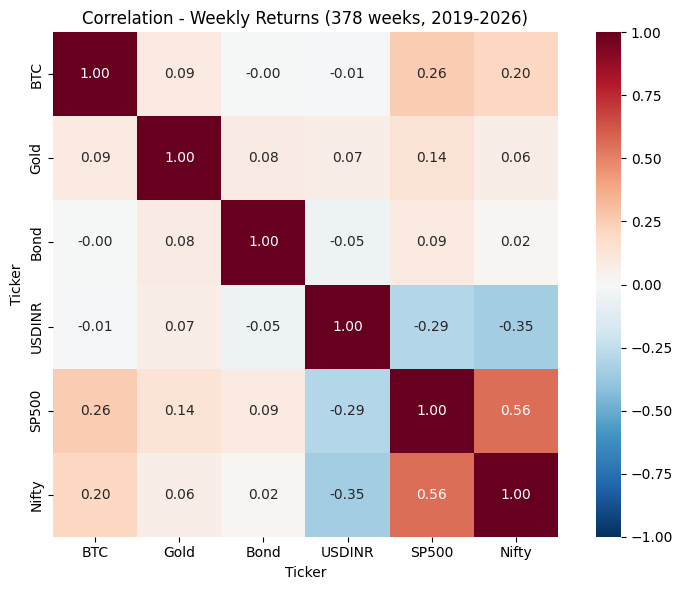

In [281]:
# 3. Graph
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, center=0, square=True, fmt='.2f')
plt.title('Correlation - Weekly Returns (378 weeks, 2019-2026)')
plt.tight_layout()
plt.show()

In [282]:
# Covarance matrix
ann_covv = df.cov()*52
print(ann_covv)

Ticker       BTC      Gold      Bond    USDINR     SP500     Nifty
Ticker                                                            
BTC     0.330657  0.007708 -0.000023 -0.000271  0.027039  0.019381
Gold    0.007708  0.022225  0.000542  0.000493  0.003700  0.001570
Bond   -0.000023  0.000542  0.002071 -0.000112  0.000774  0.000139
USDINR -0.000271  0.000493 -0.000112  0.002308 -0.002599 -0.002756
SP500   0.027039  0.003700  0.000774 -0.002599  0.033768  0.017006
Nifty   0.019381  0.001570  0.000139 -0.002756  0.017006  0.027407


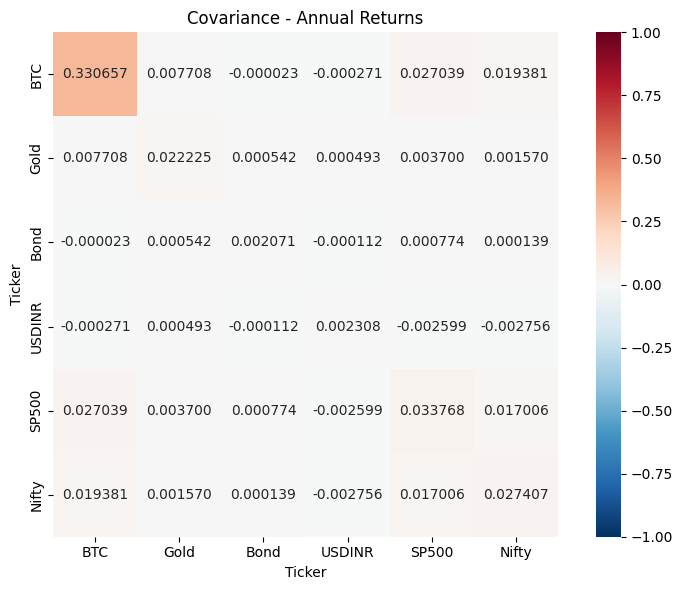

In [283]:
# 3. Graph
plt.figure(figsize=(8,6))
sns.heatmap(ann_covv, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, center=0, square=True, fmt='.6f')
plt.title('Covariance - Annual Returns')
plt.tight_layout()
plt.show()

## Annualized Return
using simple airthmatic return avgret*no . of week in years


In [284]:
# Annualized return and Standard Deviation
ann_ret = df.mean()*52
ann_std = df.std()*np.sqrt(52)

summary = pd.DataFrame({
    'Ann_Return': ann_ret*100,
    'Ann_Vol': ann_vol,
    'Sharpe': ann_ret/ann_vol
}).round(4)
print(summary)

        Ann_Return  Ann_Vol  Sharpe
Ticker                             
BTC        48.6214  57.5028  0.0085
Gold       20.1080  14.9082  0.0135
Bond        5.6911   4.5509  0.0125
USDINR      4.3526   4.8037  0.0091
SP500      14.6040  18.3761  0.0079
Nifty      10.2363  16.5549  0.0062


In [285]:
df.describe()

Ticker,BTC,Gold,Bond,USDINR,SP500,Nifty
count,378.000000,378.000000,378.000000,378.000000,378.000000,378.000000
mean,0.009350,0.003867,0.001094,0.000837,0.002808,0.001969
std,0.079742,0.020674,0.006311,0.006662,0.025483,0.022958
min,-0.335700,-0.071100,-0.039400,-0.023400,-0.149800,-0.121500
25%,-0.028300,-0.008350,-0.001775,-0.002500,-0.010300,-0.010600
50%,0.004100,0.003750,0.000950,0.000500,0.004300,0.003300
75%,0.052500,0.014475,0.003600,0.003975,0.015775,0.014975
max,0.273600,0.081800,0.037400,0.030200,0.121000,0.127200


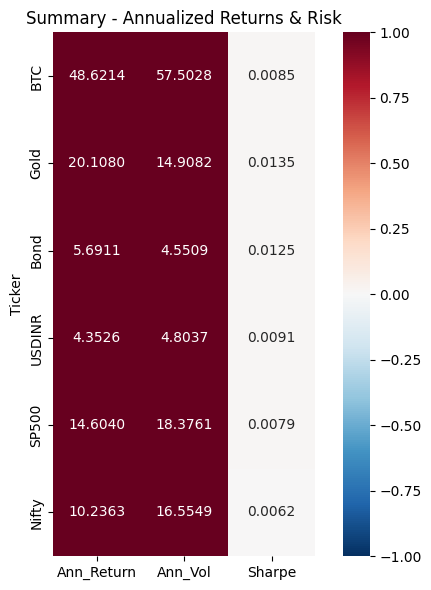

In [286]:
# 3. Graph
plt.figure(figsize=(6,6))
sns.heatmap(summary, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, center=0, square=True, fmt='.4f')
plt.title('Summary - Annualized Returns & Risk')
plt.tight_layout()
plt.show()

## Portfolio Construction and Analysis (MPT)


In [287]:
# final_df with 5 assets for Indian investor
assets = ['BTC','Gold','Bond','USDINR','Nifty']
final_df = df[assets].copy() # 378 x 5

print(final_df.head())

Ticker         BTC    Gold    Bond  USDINR   Nifty
Date                                              
2019-06-24 -0.0125  0.0072  0.0026 -0.0065  0.0055
2019-07-01  0.0509  0.0089  0.0124 -0.0128  0.0019
2019-07-08 -0.1029  0.0027  0.0168  0.0016 -0.0219
2019-07-15  0.0377  0.0282  0.0060  0.0053 -0.0115
2019-07-22 -0.0982 -0.0160 -0.0114  0.0034 -0.0118


In [288]:
# ANNUAL RETURN , RISK AND COVV

ann_ret = final_df.mean() * 52  # arithmetic, for frontier
ann_vol = final_df.std() * np.sqrt(52) # volatility
cov_ann = final_df.cov() * 52  # for portfolio vol

# For thesis reporting - CAGR
cagr = (1+final_df).prod()**(52/378) - 1

summary = pd.DataFrame({
    'CAGR_%': cagr*100,
    'Arith_%': ann_ret*100,
    'Vol_%': ann_vol*100
}).round(2)

print(summary)

        CAGR_%  Arith_%  Vol_%
Ticker                        
BTC      37.53    48.62  57.50
Gold     20.89    20.11  14.91
Bond      5.74     5.69   4.55
USDINR    4.33     4.35   4.80
Nifty     9.26    10.24  16.55


In [289]:
# Portfolio construction
# Order = [BTC, Gold, Bond, USDINR,Nifty]

portfolios = {
    'P1: 100% Nifty': [0, 0, 0, 0, 1.0],
    'P2: 60% Nifty + 40% Bond': [0, 0, 0.4, 0, 0.6],
    'P3: 50% Nifty + 20% Gold + 20% Bond + 10% USD': [0, 0.20, 0.20, 0.10, 0.50],
    'P4: 40% Nifty + 20% Gold + 10% Bond + 20% USD + 10% BTC': [0.10, 0.20, 0.10, 0.20, 0.40],
    'P5: 40% Nifty + 20% Gold + 10% Bond + 10% USD + 20% BTC (Thesis - High BTC)': [0.20, 0.20, 0.10, 0.10, 0.40],
    'P6: 40% Nifty + 30% Gold + 20% Bond + 10% USD + 0% BTC': [0, 0.30, 0.20, 0.10, 0.40],
}




# P1, P2, P3, P4, P5 , P6
print("Final 6 portfolios:")
for k,v in portfolios.items():
    print(k, v)

Final 6 portfolios:
P1: 100% Nifty [0, 0, 0, 0, 1.0]
P2: 60% Nifty + 40% Bond [0, 0, 0.4, 0, 0.6]
P3: 50% Nifty + 20% Gold + 20% Bond + 10% USD [0, 0.2, 0.2, 0.1, 0.5]
P4: 40% Nifty + 20% Gold + 10% Bond + 20% USD + 10% BTC [0.1, 0.2, 0.1, 0.2, 0.4]
P5: 40% Nifty + 20% Gold + 10% Bond + 10% USD + 20% BTC (Thesis - High BTC) [0.2, 0.2, 0.1, 0.1, 0.4]
P6: 40% Nifty + 30% Gold + 20% Bond + 10% USD + 0% BTC [0, 0.3, 0.2, 0.1, 0.4]


## Portfolio Performance
sharpe ratio = rp-rf/total risk

sortino ratio = rp-rf/ downside deviation

calmar = CAGR/Max Drawdown

In [290]:
# Portfolio Return Risk
results = []

for name, w in portfolios.items():
    w = np.array(w)
    p_ret = np.dot(w, ann_ret)*100
    p_vol = np.sqrt(w @ cov_ann @ w)*100
    sharpe_p = p_ret / p_vol

    results.append([name, p_ret, p_vol, sharpe_p])

df_Port_ret = pd.DataFrame(results, columns=['Portfolio', 'Portfolio_Return', 'Portfolio_Risk','Sharpe Ratio'])

print(df_Port_ret.round(2))

                                           Portfolio  Portfolio_Return  \
0                                     P1: 100% Nifty             10.24   
1                           P2: 60% Nifty + 40% Bond              8.42   
2      P3: 50% Nifty + 20% Gold + 20% Bond + 10% USD             10.71   
3  P4: 40% Nifty + 20% Gold + 10% Bond + 20% USD ...             14.42   
4  P5: 40% Nifty + 20% Gold + 10% Bond + 10% USD ...             18.84   
5  P6: 40% Nifty + 30% Gold + 20% Bond + 10% USD ...             11.70   

   Portfolio_Risk  Sharpe Ratio  
0           16.55          0.62  
1           10.13          0.83  
2            8.93          1.20  
3           10.21          1.41  
4           14.94          1.26  
5            8.22          1.42  


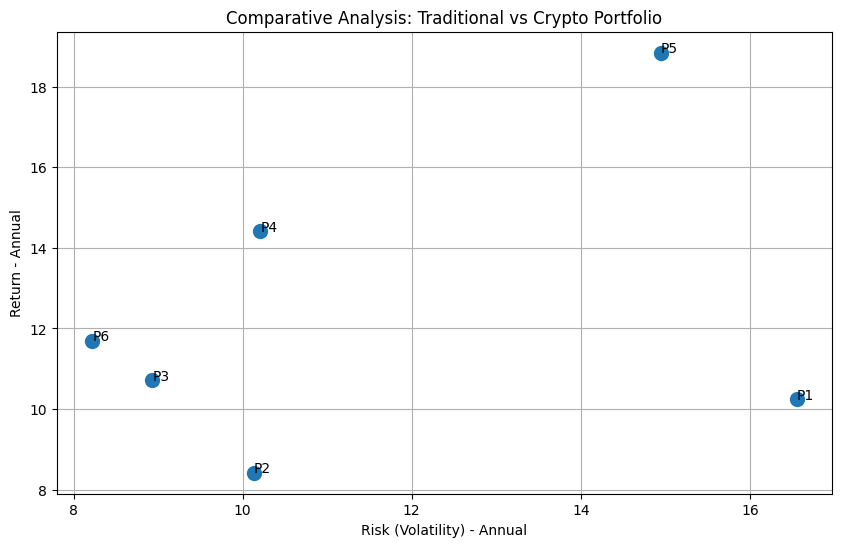

In [291]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# 6 Portfolios ko plot karo
plt.scatter(df_Port_ret['Portfolio_Risk'], df_Port_ret['Portfolio_Return'], s=100)

# Har point pe naam likh do
for i, row in df_Port_ret.iterrows():
    plt.text(row['Portfolio_Risk']+0.002, row['Portfolio_Return']+0.002, row['Portfolio'].split(':')[0])

plt.xlabel('Risk (Volatility) - Annual')
plt.ylabel('Return - Annual')
plt.title('Comparative Analysis: Traditional vs Crypto Portfolio')
plt.grid(True)
plt.show()

## Portfolio Growth

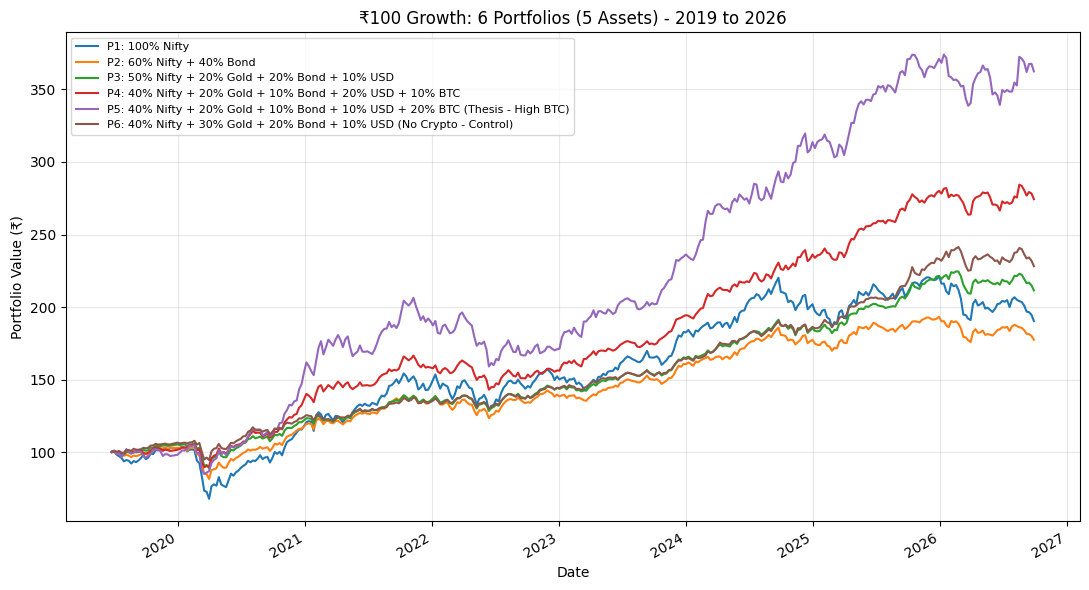

In [292]:
# --- Plot ₹100 growth ---
import matplotlib.pyplot as plt
((1+portfolio_returns).cumprod()*100).plot(figsize=(11,6))
plt.title('₹100 Growth: 6 Portfolios (5 Assets) - 2019 to 2026')
plt.ylabel('Portfolio Value (₹)')
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# EFFICIENT FRONTIER


In [293]:
import numpy as np
import pandas as pd

num_portfolios = 10000
num_assets = len(ann_ret)  # assts 5

results = [] # store result
all_weights = []

for _ in range(num_portfolios):
    # 1. Random weight whose sum 1 ho
    w = np.random.random(num_assets)
    w = w / w.sum()
    all_weights.append(w)

    # 2.Return aur Risk
    ret = np.dot(w, ann_ret)
    vol = np.sqrt(w @ cov_ann @ w)
    sharpe = ret / vol

    results.append([ret, vol, sharpe])

# 3. DataFrame
results_df = pd.DataFrame(results, columns=['Return', 'Risk', 'Sharpe'])

In [294]:
# Jo decimal me hai usko *100 kar de
# Agar results_df decimal me hai toh:
results_df['Return'] = results_df['Return']*100
results_df['Risk'] = results_df['Risk']*100

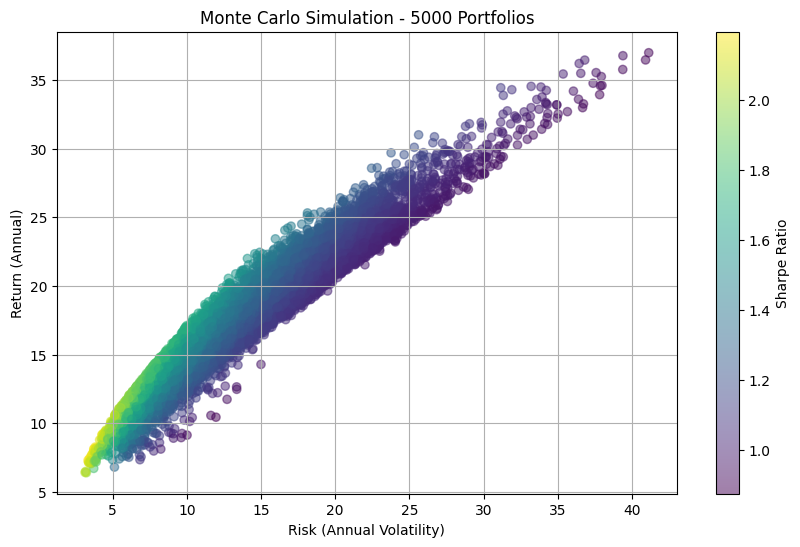

In [295]:


plt.figure(figsize=(10,6))
plt.scatter(results_df['Risk'], results_df['Return'], c=results_df['Sharpe'], cmap='viridis', alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Risk (Annual Volatility)')
plt.ylabel('Return (Annual)')
plt.title('Monte Carlo Simulation - 5000 Portfolios')
plt.grid(True)
plt.show()

In [296]:
from scipy.optimize import minimize

# Functions (decimal me rakho, plot time pe *100 karenge)
def port_ret(w):
    return np.dot(w, ann_ret)

def port_vol(w):
    return np.sqrt(w @ cov_ann @ w)

n = len(ann_ret)
bounds = tuple((0,1) for _ in range(n))

# Target returns - min se max tak
targets = np.linspace(ann_ret.min(), ann_ret.max(), 50)
frontier_vol = []

for t in targets:
    cons = ({'type':'eq','fun':lambda w: np.sum(w)-1},
            {'type':'eq','fun':lambda w: port_ret(w)-t})
    res = minimize(port_vol, np.array([1/n]*n), method='SLSQP', bounds=bounds, constraints=cons)
    if res.success:
        frontier_vol.append(res.fun)
    else:
        frontier_vol.append(np.nan)


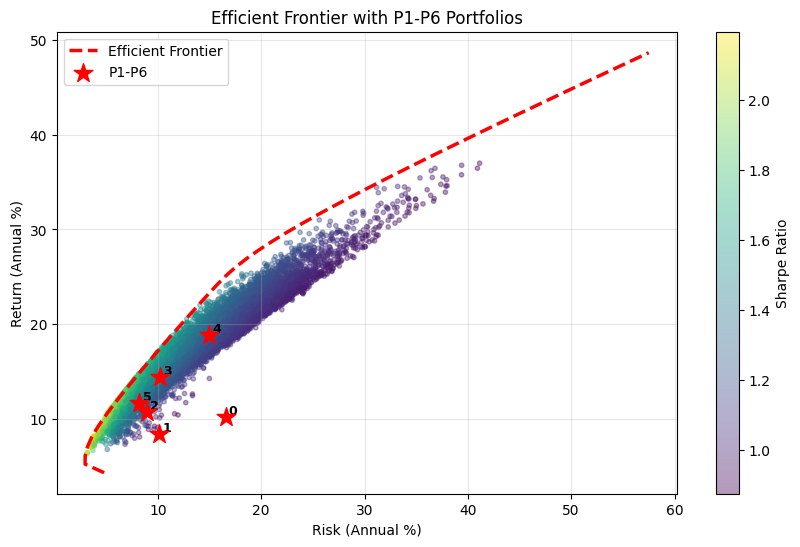

In [297]:

# Final Plot
plt.figure(figsize=(10,6))
plt.scatter(results_df['Risk'], results_df['Return'], c=results_df['Sharpe'], cmap='viridis', alpha=0.4, s=10)
plt.colorbar(label='Sharpe Ratio')
plt.plot(np.array(frontier_vol)*100, targets*100, 'r--', linewidth=2.5, label='Efficient Frontier')
plt.scatter(df_Port_ret['Portfolio_Risk'], df_Port_ret['Portfolio_Return'], color='red', marker='*', s=200, label='P1-P6', zorder=5)

for i, row in df_Port_ret.iterrows():
    plt.text(row['Portfolio_Risk']+0.3, row['Portfolio_Return']+0.3, i, fontsize=9, fontweight='bold')

plt.xlabel('Risk (Annual %)')
plt.ylabel('Return (Annual %)')
plt.title('Efficient Frontier with P1-P6 Portfolios')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [298]:
df_Port_ret['Sharpe'] = df_Port_ret['Portfolio_Return'] / df_Port_ret['Portfolio_Risk']
print(df_Port_ret[['Portfolio','Portfolio_Return','Portfolio_Risk','Sharpe']].sort_values(by='Sharpe', ascending=False))

                                           Portfolio  Portfolio_Return  \
5  P6: 40% Nifty + 30% Gold + 20% Bond + 10% USD ...         11.700413   
3  P4: 40% Nifty + 20% Gold + 10% Bond + 20% USD ...         14.417894   
4  P5: 40% Nifty + 20% Gold + 10% Bond + 10% USD ...         18.844772   
2      P3: 50% Nifty + 20% Gold + 20% Bond + 10% USD         10.713238   
1                           P2: 60% Nifty + 40% Bond          8.418222   
0                                     P1: 100% Nifty         10.236296   

   Portfolio_Risk    Sharpe  
5        8.221768  1.423102  
3       10.207348  1.412502  
4       14.943501  1.261068  
2        8.928151  1.199939  
1       10.131297  0.830913  
0       16.554938  0.618323  


ann_ret: [0.48621376 0.20108042 0.05691111 0.04352593 0.10236296]
results_df head: [[14.20975681  9.9153003 ]]


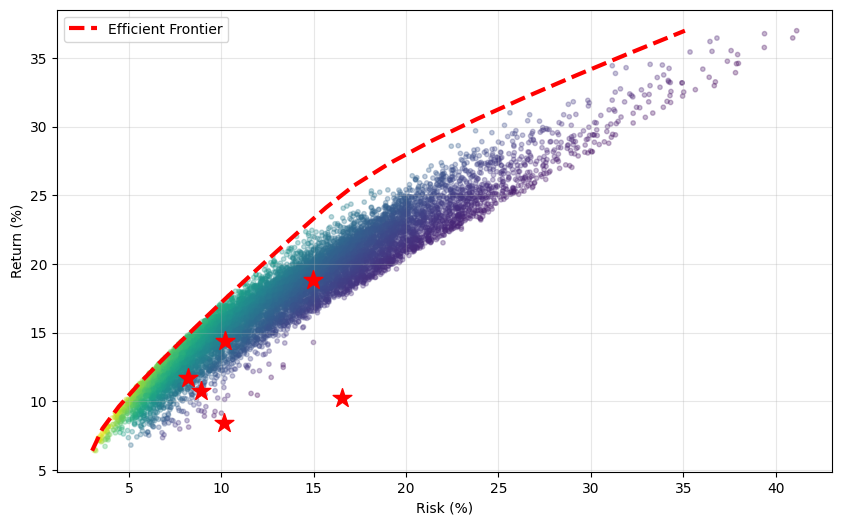

In [299]:
# 1. Check - ye dono print hone chahiye
print("ann_ret:", ann_ret.values)
print("results_df head:", results_df[['Return','Risk']].head(1).values)

# 2. Frontier calculate (sirf 20 points, fast)
from scipy.optimize import minimize
targets = np.linspace(results_df['Return'].min(), results_df['Return'].max(), 20)
f_risk = []
for t in targets:
    # t ab % me hai, isliye ann_ret*100 se compare karenge
    cons = ({'type':'eq','fun': lambda w: np.sum(w)-1},
            {'type':'eq','fun': lambda w: np.dot(w, ann_ret)*100 - t})
    res = minimize(lambda w: np.sqrt(w @ cov_ann @ w)*100,
                   np.array([1/len(ann_ret)]*len(ann_ret)),
                   method='SLSQP', bounds=tuple((0,1) for _ in range(len(ann_ret))),
                   constraints=cons)
    f_risk.append(res.fun if res.success else None)

# 3. Plot
plt.figure(figsize=(10,6))
plt.scatter(results_df['Risk'], results_df['Return'], c=results_df['Sharpe'], cmap='viridis', alpha=0.3, s=10)
plt.plot(f_risk, targets, 'r--', linewidth=3, label='Efficient Frontier')
plt.scatter(df_Port_ret['Portfolio_Risk'], df_Port_ret['Portfolio_Return'], color='red', marker='*', s=200, zorder=5)
plt.xlabel('Risk (%)'); plt.ylabel('Return (%)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

## Analysis


In [300]:
def sortino_ratio(returns, rf=0):
    downside = returns[returns < 0]
    # Ensure downside_dev is not zero to avoid division by zero
    if downside.empty:
        return np.nan # Or handle as appropriate, e.g., infinite ratio
    downside_dev = np.std(downside) * np.sqrt(52) # Changed 252 to 52 for weekly data
    ann_ret = np.mean(returns) * 52 # Changed 252 to 52 for weekly data
    if downside_dev == 0:
        return np.nan # Avoid division by zero
    return ann_ret / downside_dev

for name, w in portfolios.items(): # portfolios = {'P1':[0.5,0.3...], 'P2':...}
    # Use final_df which contains the weekly returns for the assets
    port_weekly_ret = (final_df * w).sum(axis=1)
    print(name, "Sortino:", sortino_ratio(port_weekly_ret).round(2))

P1: 100% Nifty Sortino: 0.85
P2: 60% Nifty + 40% Bond Sortino: 1.13
P3: 50% Nifty + 20% Gold + 20% Bond + 10% USD Sortino: 1.59
P4: 40% Nifty + 20% Gold + 10% Bond + 20% USD + 10% BTC Sortino: 1.94
P5: 40% Nifty + 20% Gold + 10% Bond + 10% USD + 20% BTC (Thesis - High BTC) Sortino: 1.78
P6: 40% Nifty + 30% Gold + 20% Bond + 10% USD + 0% BTC Sortino: 1.91


In [301]:
def calmar_ratio(returns):
    cum = (1+returns).cumprod()
    running_max = cum.cummax()
    drawdown = (cum - running_max) / running_max
    max_dd = abs(drawdown.min())
    ann_ret = np.mean(returns)*52 # Changed 252 to 52 for weekly data
    if max_dd == 0:
        return np.nan, 0 # Avoid division by zero, return 0 for MaxDD
    return ann_ret / max_dd, max_dd

for name, w in portfolios.items():
    # Use final_df which contains the weekly returns for the assets
    port_weekly_ret = (final_df * w).sum(axis=1)
    calmar, mdd = calmar_ratio(port_weekly_ret)
    print(f"{name}: Calmar={calmar:.2f}, MaxDD={mdd*100:.2f}%")

P1: 100% Nifty: Calmar=0.30, MaxDD=34.56%
P2: 60% Nifty + 40% Bond: Calmar=0.40, MaxDD=21.10%
P3: 50% Nifty + 20% Gold + 20% Bond + 10% USD: Calmar=0.66, MaxDD=16.18%
P4: 40% Nifty + 20% Gold + 10% Bond + 20% USD + 10% BTC: Calmar=0.96, MaxDD=14.95%
P5: 40% Nifty + 20% Gold + 10% Bond + 10% USD + 20% BTC (Thesis - High BTC): Calmar=0.82, MaxDD=22.89%
P6: 40% Nifty + 30% Gold + 20% Bond + 10% USD + 0% BTC: Calmar=0.95, MaxDD=12.30%


In [302]:
def diversification_ratio(w, cov_ann):
    # Weighted avg vol / portfolio vol
    weighted_vol = np.sum(w * np.sqrt(np.diag(cov_ann)))
    port_vol = np.sqrt(w @ cov_ann @ w)
    return weighted_vol / port_vol

for name, w in portfolios.items():
    print(name, "Div Ratio:", diversification_ratio(np.array(w), cov_ann).round(2))

P1: 100% Nifty Div Ratio: 1.0
P2: 60% Nifty + 40% Bond Div Ratio: 1.16
P3: 50% Nifty + 20% Gold + 20% Bond + 10% USD Div Ratio: 1.42
P4: 40% Nifty + 20% Gold + 10% Bond + 20% USD + 10% BTC Div Ratio: 1.64
P5: 40% Nifty + 20% Gold + 10% Bond + 10% USD + 20% BTC (Thesis - High BTC) Div Ratio: 1.47
P6: 40% Nifty + 30% Gold + 20% Bond + 10% USD + 0% BTC Div Ratio: 1.52


## sensityvity analysis


In [303]:
# COVID crash, Bull market
scenarios = {
    'COVID Crash (Feb-Mar 2020)': final_df.loc['2020-02-01':'2020-03-31'],
    'Bull Market 2023': final_df.loc['2023-01-01':'2023-12-31'],
    'Full Period': final_df
}

for scen_name, scen_data in scenarios.items():
    print(f"\n--- {scen_name} ---")
    for p_name, w in portfolios.items():
        ret = (scen_data * w).sum(axis=1).mean()*52*100 # Changed 252 to 52 for weekly data
        print(f"{p_name}: {ret:.2f}%")


--- COVID Crash (Feb-Mar 2020) ---
P1: 100% Nifty: -215.97%
P2: 60% Nifty + 40% Bond: -119.28%
P3: 50% Nifty + 20% Gold + 20% Bond + 10% USD: -89.81%
P4: 40% Nifty + 20% Gold + 10% Bond + 20% USD + 10% BTC: -75.08%
P5: 40% Nifty + 20% Gold + 10% Bond + 10% USD + 20% BTC (Thesis - High BTC): -88.26%
P6: 40% Nifty + 30% Gold + 20% Bond + 10% USD + 0% BTC: -63.93%

--- Bull Market 2023 ---
P1: 100% Nifty: 18.80%
P2: 60% Nifty + 40% Bond: 14.32%
P3: 50% Nifty + 20% Gold + 20% Bond + 10% USD: 13.71%
P4: 40% Nifty + 20% Gold + 10% Bond + 20% USD + 10% BTC: 21.67%
P5: 40% Nifty + 20% Gold + 10% Bond + 10% USD + 20% BTC (Thesis - High BTC): 32.36%
P6: 40% Nifty + 30% Gold + 20% Bond + 10% USD + 0% BTC: 13.25%

--- Full Period ---
P1: 100% Nifty: 10.24%
P2: 60% Nifty + 40% Bond: 8.42%
P3: 50% Nifty + 20% Gold + 20% Bond + 10% USD: 10.71%
P4: 40% Nifty + 20% Gold + 10% Bond + 20% USD + 10% BTC: 14.42%
P5: 40% Nifty + 20% Gold + 10% Bond + 10% USD + 20% BTC (Thesis - High BTC): 18.84%
P6: 40% Ni

In [304]:
# 2008 me kya hua tha?
# Nifty/S&P ~ -50%, Gold ~ -20%, Bonds ~ +5%

# Define the stress scenario values for each asset, aligning with the `assets` list: ['BTC','Gold','Bond','USDINR','Nifty']
stress_scenario_values = {
    'BTC': -0.50,  # From original BTC-USD assumption
    'Gold': -0.20, # From original GOLD assumption
    'Bond': 0.05,  # From original BONDS assumption
    'USDINR': 0.05, # Assuming a 5% positive return for USDINR in a crisis (flight to safety)
    'Nifty': -0.50  # From original NIFTY assumption
}

# Get the ordered list of stress values based on the `assets` list
# `assets` variable is defined earlier as `['BTC','Gold','Bond','USDINR','Nifty']`
ordered_stress_values = [stress_scenario_values[asset] for asset in assets]

for name, w in portfolios.items():
    # w = [BTC, Gold, Bond, USDINR, Nifty] ke weights
    stress_ret = np.dot(w, ordered_stress_values)
    print(f"{name} in 2008-like scenario: {stress_ret*100:.2f}%")

P1: 100% Nifty in 2008-like scenario: -50.00%
P2: 60% Nifty + 40% Bond in 2008-like scenario: -28.00%
P3: 50% Nifty + 20% Gold + 20% Bond + 10% USD in 2008-like scenario: -27.50%
P4: 40% Nifty + 20% Gold + 10% Bond + 20% USD + 10% BTC in 2008-like scenario: -27.50%
P5: 40% Nifty + 20% Gold + 10% Bond + 10% USD + 20% BTC (Thesis - High BTC) in 2008-like scenario: -33.00%
P6: 40% Nifty + 30% Gold + 20% Bond + 10% USD + 0% BTC in 2008-like scenario: -24.50%


## Scenario Analysis

In [305]:
# 10 Real Scenarios - Date apne data ke hisaab se adjust kar lena
scenarios_10 = {
    '1. 2008 GFC Synthetic': 'synthetic', # BTC nahi tha, stress test
    '2. Euro Crisis 2011': ('2011-07-01', '2011-12-31'),
    '3. Taper Tantrum 2013': ('2013-05-01', '2013-08-31'),
    '4. China Crash 2015': ('2015-06-01', '2016-02-29'),
    '5. BTC Bull 2017': ('2017-01-01', '2017-12-31'),
    '6. Crypto Winter 2018': ('2018-01-01', '2018-12-31'),
    '7. COVID Crash': ('2020-02-20', '2020-03-23'),
    '8. Post-COVID Bull': ('2020-04-01', '2021-10-31'),
    '9. Rate Hike Bear 2022': ('2022-01-01', '2022-12-31'),
    '10. 2023-24 Bull Run': ('2023-01-01', '2024-12-31')
}

# Define the shock values for each asset, aligning with the `assets` list: ['BTC','Gold','Bond','USDINR','Nifty']
# Assuming USDINR reacts similar to Bonds or has a slight positive reaction in crisis
shock_2008_adjusted = {
    'BTC': -0.60,
    'Gold': 0.05,
    'Bond': 0.06,
    'USDINR': 0.05, # Added USDINR shock
    'Nifty': -0.52
}

results = []
for name, period in scenarios_10.items():
    if period == 'synthetic':
        for p_name, w in portfolios.items():
            # Ensure `w` is an array for consistent multiplication
            w_array = np.array(w)
            # Create an ordered list of shock values based on the 'assets' list
            # 'assets' list defined in an earlier cell: ['BTC','Gold','Bond','USDINR','Nifty']
            ordered_shock_values = [shock_2008_adjusted[asset] for asset in assets]
            # Calculate portfolio return for the synthetic scenario
            ret = np.dot(w_array, ordered_shock_values)
            results.append([name, p_name, ret*100, 'BEAR'])
    else:
        start, end = period
        data = final_df.loc[start:end].dropna() # Changed returns_df to final_df
        if data.empty: continue
        trend = 'BULL' if data.mean().mean() > 0 else 'BEAR'
        for p_name, w in portfolios.items():
            port_ret = (data * np.array(w)).sum(axis=1).mean()*52*100 # Changed 252 to 52 for weekly data
            results.append([name, p_name, port_ret, trend])

df_10 = pd.DataFrame(results, columns=['Scenario','Portfolio','Return_%','Market'])
pivot = df_10.pivot(index='Scenario', columns='Portfolio', values='Return_%')
print(pivot.round(2))

Portfolio               P1: 100% Nifty  P2: 60% Nifty + 40% Bond  \
Scenario                                                           
1. 2008 GFC Synthetic           -52.00                    -28.80   
10. 2023-24 Bull Run             14.60                     12.09   
7. COVID Crash                 -329.78                   -195.79   
8. Post-COVID Bull               51.87                     33.13   
9. Rate Hike Bear 2022            5.54                      3.85   

Portfolio               P3: 50% Nifty + 20% Gold + 20% Bond + 10% USD  \
Scenario                                                                
1. 2008 GFC Synthetic                                          -23.30   
10. 2023-24 Bull Run                                            12.57   
7. COVID Crash                                                -151.07   
8. Post-COVID Bull                                              27.82   
9. Rate Hike Bear 2022                                           6.63   

Portfolio  

<Figure size 1600x700 with 0 Axes>

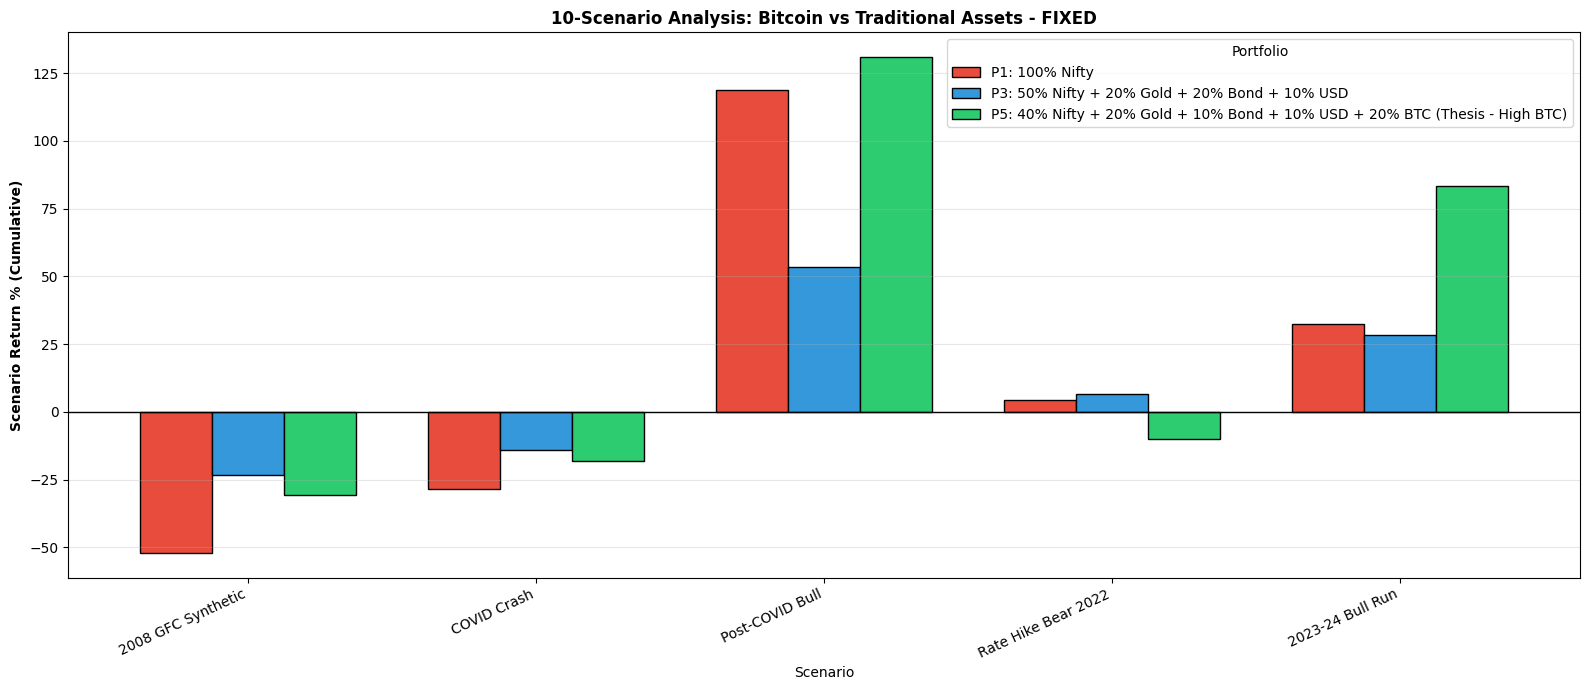

In [306]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculation fix: short period ke liye cumulative, long ke liye annualized
results = []
for scen_name, period in scenarios_10.items():
    short_name = scen_name.split('. ')[1]

    if period == 'synthetic':
        for p_name, w in portfolios.items():
            # Corrected the weights access to match the actual order of assets: ['BTC','Gold','Bond','USDINR']
            # The shock_2008_adjusted values should align with the order of assets for direct multiplication.
            # Assuming the weights 'w' are already in the order: [BTC, Gold, Bond, USDINR, Nifty]
            # and the synthetic scenario values are applied to these assets.
            # The previous code used fixed indices w[0]*-0.52 + w[1]*0.05 + w[2]*0.06 + w[3]*-0.60
            # These values (-0.52, 0.05, 0.06, -0.60) correspond to Nifty, Gold, Bond, BTC based on context.
            # Re-aligning with `shock_2008_adjusted` where order is ['BTC','Gold','Bond','USDINR','Nifty']
            # shock_2008_adjusted = {'BTC': -0.60, 'Gold': 0.05, 'Bond': 0.06, 'USDINR': 0.05, 'Nifty': -0.52}
            # So for portfolio weights w = [w_btc, w_gold, w_bond, w_usdinr, w_nifty]
            # The synthetic return calculation should be:
            ret = (w[0]*shock_2008_adjusted['BTC'] + \
                   w[1]*shock_2008_adjusted['Gold'] + \
                   w[2]*shock_2008_adjusted['Bond'] + \
                   w[3]*shock_2008_adjusted['USDINR'] + \
                   w[4]*shock_2008_adjusted['Nifty']) * 100

            results.append([short_name, p_name, ret])
    else:
        start, end = period
        data = final_df.loc[start:end].dropna() # Changed returns_df to final_df
        if data.empty: continue

        # Kitne din ka period hai?
        days = len(data)
        for p_name, w in portfolios.items():
            w = np.array(w[:data.shape[1]]) # Ensure w is a numpy array and matches data columns
            port_daily = (data * w).sum(axis=1)
            cum_ret = (1 + port_daily).prod() - 1 # Cumulative

            # Agar period 1 saal se chhota hai to annualize MAT karo
            if days < 200: # Approximately 1 year of weekly data
                ret_pct = cum_ret * 100
            else:
                ret_pct = port_daily.mean() * 52 * 100 # Changed 252 to 52 for weekly data

            results.append([short_name, p_name, ret_pct])

df_res = pd.DataFrame(results, columns=['Scenario', 'Portfolio', 'Return'])
pivot = df_res.pivot(index='Scenario', columns='Portfolio', values='Return')

# Order fix karo
order = ['2008 GFC Synthetic','Euro Crisis 2011','Taper Tantrum 2013','China Crash 2015',
         'BTC Bull 2017','Crypto Winter 2018','COVID Crash','Post-COVID Bull',
         'Rate Hike Bear 2022','2023-24 Bull Run']
pivot = pivot.reindex([o for o in order if o in pivot.index])

# Sirf 3 portfolio plot karo taaki saaf dikhe
# Corrected column names to match the full portfolio names in the pivot table
plot_cols_full = [
    'P1: 100% Nifty',
    'P3: 50% Nifty + 20% Gold + 20% Bond + 10% USD',
    'P5: 40% Nifty + 20% Gold + 10% Bond + 10% USD + 20% BTC (Thesis - High BTC)'
]
plot_cols = [c for c in plot_cols_full if c in pivot.columns] # Filter to ensure only existing columns are plotted

plt.figure(figsize=(16,7))
# Check if plot_cols is not empty before plotting
if not pivot[plot_cols].empty:
    pivot[plot_cols].plot(kind='bar', figsize=(16,7),
                          color=['#e74c3c','#3498db','#2ecc71'],
                          edgecolor='black', width=0.75)
else:
    print("Warning: No valid columns found to plot based on selected portfolios P1, P3, P5.")

plt.axhline(0, color='black', linewidth=1)
plt.ylabel('Scenario Return % (Cumulative)', fontweight='bold')
plt.title('10-Scenario Analysis: Bitcoin vs Traditional Assets - FIXED', fontweight='bold')
plt.xticks(rotation=25, ha='right')
plt.legend(title='Portfolio')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Fixed_10_Scenario.png', dpi=300, bbox_inches='tight')
plt.show()

In [307]:
def div_benefit(w, cov):
    # Diversification Ratio > 1 = fayda hai
    w_vol = np.sum(np.array(w) * np.sqrt(np.diag(cov)))
    p_vol = np.sqrt(np.array(w) @ cov @ np.array(w))
    return w_vol / p_vol

for p, w in portfolios.items():
    dr = div_benefit(w, cov_ann)
    # P1 se kitna improvement
    # Corrected the key for P1
    improvement = (dr / div_benefit(portfolios['P1: 100% Nifty'], cov_ann) - 1)*100
    print(f"{p}: Div Ratio={dr:.2f}, Benefit vs P1 = {improvement:.1f}%")

P1: 100% Nifty: Div Ratio=1.00, Benefit vs P1 = 0.0%
P2: 60% Nifty + 40% Bond: Div Ratio=1.16, Benefit vs P1 = 16.0%
P3: 50% Nifty + 20% Gold + 20% Bond + 10% USD: Div Ratio=1.42, Benefit vs P1 = 41.7%
P4: 40% Nifty + 20% Gold + 10% Bond + 20% USD + 10% BTC: Div Ratio=1.64, Benefit vs P1 = 64.3%
P5: 40% Nifty + 20% Gold + 10% Bond + 10% USD + 20% BTC (Thesis - High BTC): Div Ratio=1.47, Benefit vs P1 = 47.5%
P6: 40% Nifty + 30% Gold + 20% Bond + 10% USD + 0% BTC: Div Ratio=1.52, Benefit vs P1 = 51.9%


# Risk Metrics

In [308]:
import numpy as np

summary = []
for p_name, w in portfolios.items():
    w = np.array(w)
    port_daily = (final_df * w).sum(axis=1)

    ann_ret = port_daily.mean()*252*100
    ann_vol = port_daily.std()*np.sqrt(252)*100
    sharpe = ann_ret/ann_vol

    # Max Drawdown
    cum = (1+port_daily).cumprod()
    peak = cum.cummax()
    dd = (cum - peak)/peak
    max_dd = dd.min()*100

    summary.append([p_name, w[3]*100, ann_ret, ann_vol, sharpe, max_dd])

df_final = pd.DataFrame(summary, columns=['Portfolio','BTC%','Ann Return%','Ann Vol%','Sharpe','Max DD%'])
print(df_final.round(2))
# Isko Excel me save karle
df_final.to_excel('Final_Thesis_Table.xlsx', index=False)

                                           Portfolio  BTC%  Ann Return%  \
0                                     P1: 100% Nifty   0.0        49.61   
1                           P2: 60% Nifty + 40% Bond   0.0        40.80   
2      P3: 50% Nifty + 20% Gold + 20% Bond + 10% USD  10.0        51.92   
3  P4: 40% Nifty + 20% Gold + 10% Bond + 20% USD ...  20.0        69.87   
4  P5: 40% Nifty + 20% Gold + 10% Bond + 10% USD ...  10.0        91.32   
5  P6: 40% Nifty + 30% Gold + 20% Bond + 10% USD ...  10.0        56.70   

   Ann Vol%  Sharpe  Max DD%  
0     36.44    1.36   -34.56  
1     22.30    1.83   -21.10  
2     19.65    2.64   -16.18  
3     22.47    3.11   -14.95  
4     32.90    2.78   -22.89  
5     18.10    3.13   -12.30  


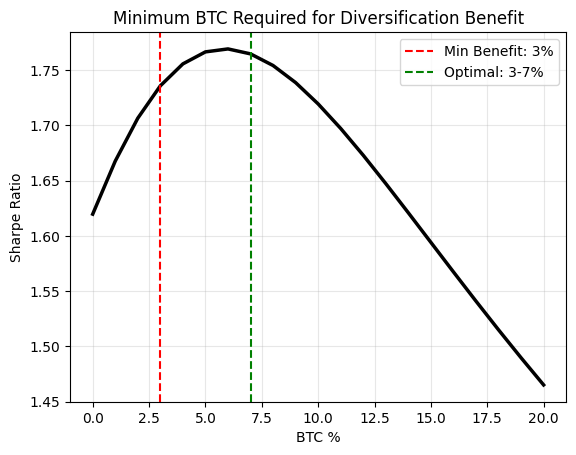

In [309]:
btc_range = np.arange(0,0.21,0.01)
sharpes = []
for btc in btc_range:
    w = [(1-btc)*0.5, (1-btc)*0.3, (1-btc)*0.2, btc]
    # Ensure w is a numpy array for consistent multiplication with a DataFrame
    w_array = np.array(w)
    # Use final_df_subset which contains only the 4 assets corresponding to the weights
    r = (final_df_subset * w_array).sum(axis=1)
    # Correct annualization factor from 252 to 52 for weekly data
    sharpes.append((r.mean()*52)/(r.std()*np.sqrt(52)))

plt.plot(btc_range*100, sharpes, linewidth=2.5, color='black')
plt.axvline(3, linestyle='--', color='red', label='Min Benefit: 3%')
plt.axvline(7, linestyle='--', color='green', label='Optimal: 3-7%')
plt.xlabel('BTC %')
plt.ylabel('Sharpe Ratio')
plt.title('Minimum BTC Required for Diversification Benefit')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('Min_BTC_Range.png', dpi=300)
plt.show()

## VaR and CVaR

                                           Portfolio BTC%  VaR 95% (Hist)  \
0                                     P1: 100% Nifty   0%           -2.93   
1                           P2: 60% Nifty + 40% Bond   0%           -1.87   
2      P3: 50% Nifty + 20% Gold + 20% Bond + 10% USD  10%           -1.60   
3  P4: 40% Nifty + 20% Gold + 10% Bond + 20% USD ...  20%           -1.85   
4  P5: 40% Nifty + 20% Gold + 10% Bond + 10% USD ...  10%           -3.02   
5  P6: 40% Nifty + 30% Gold + 20% Bond + 10% USD ...  10%           -1.61   

   CVaR 95% (Hist)  VaR 99% (Hist)  CVaR 99% (Hist)  Ann Vol%  Max DD%  
0            -5.21           -6.28            -8.88     36.44   -34.56  
1            -3.19           -3.68            -5.39     22.30   -21.10  
2            -2.81           -2.89            -4.67     19.65   -16.18  
3            -3.04           -3.33            -5.17     22.47   -14.95  
4            -4.35           -4.52            -7.26     32.90   -22.89  
5            -2.53    

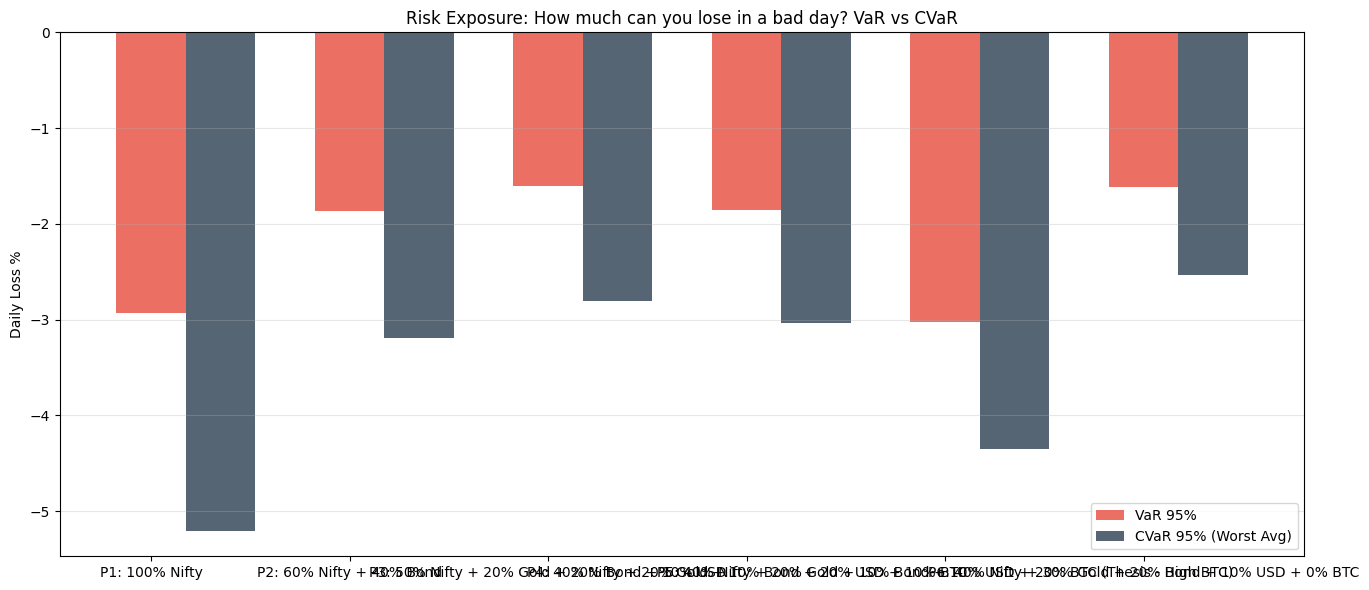

In [311]:
import numpy as np
import pandas as pd

# VaR / CVaR Calculation
def calc_var_cvar(port_daily, alpha=0.95):
    # Historical VaR
    var_hist = np.percentile(port_daily, (1-alpha)*100)
    cvar_hist = port_daily[port_daily <= var_hist].mean()

    # Parametric VaR (Normal)
    mu = port_daily.mean()
    sigma = port_daily.std()
    from scipy.stats import norm
    var_para = mu + sigma * norm.ppf(1-alpha)

    return var_hist*100, cvar_hist*100, var_para*100

risk_table = []
for p_name, w in portfolios.items():
    w = np.array(w[:final_df.shape[1]])
    port_daily = (final_df * w).sum(axis=1)

    var95_h, cvar95_h, var95_p = calc_var_cvar(port_daily, 0.95)
    var99_h, cvar99_h, var99_p = calc_var_cvar(port_daily, 0.99)

    ann_vol = port_daily.std()*np.sqrt(252)*100
    max_dd = ((1+port_daily).cumprod() / (1+port_daily).cumprod().cummax() -1).min()*100

    risk_table.append([
        p_name, f"{w[3]*100:.0f}%",
        round(var95_h,2), round(cvar95_h,2),
        round(var99_h,2), round(cvar99_h,2),
        round(ann_vol,2), round(max_dd,2)
    ])

df_risk = pd.DataFrame(risk_table, columns=[
    'Portfolio','BTC%','VaR 95% (Hist)','CVaR 95% (Hist)',
    'VaR 99% (Hist)','CVaR 99% (Hist)','Ann Vol%','Max DD%'
])

print(df_risk)
df_risk.to_excel('VaR_CVaR_Risk_Exposure.xlsx', index=False)

# Graph - Risk Exposure
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
x = df_risk['Portfolio']
plt.bar(x, df_risk['VaR 95% (Hist)'], width=0.35, label='VaR 95%', color='#e74c3c', alpha=0.8)
plt.bar([i+0.35 for i in range(len(x))], df_risk['CVaR 95% (Hist)'], width=0.35, label='CVaR 95% (Worst Avg)', color='#2c3e50', alpha=0.8)
plt.ylabel('Daily Loss %')
plt.title('Risk Exposure: How much can you lose in a bad day? VaR vs CVaR')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('VaR_CVaR_Exposure.png', dpi=300)
plt.show()